# Encontro 1 — Introdução à pesquisa quantitativa e ao Google Colab

**Disciplina:** Métodos e Técnicas de Pesquisa Quantitativa — Administração/UFMA
**Docente:** Prof. Dr. Tadeu Gomes Teixeira

Neste notebook você vai:
1. Aprender o que é um notebook e como executar células;
2. Conhecer o mínimo de Python necessário para a disciplina;
3. Carregar dados **reais** do IBGE sobre as empresas brasileiras;
4. Produzir seu primeiro gráfico e interpretá-lo.

**Como usar:** execute as células na ordem, com `Shift+Enter`. As lacunas para você completar
estão marcadas com `# === COMPLETE AQUI ===`.

> **📌 Nota de condução** — Reserve ~15 min para esta seção inicial. Peça que todos executem a célula de identificação antes de avançar; quem ficar travado no acesso ao Colab resolve com o colega ao lado enquanto você circula. Mostre desde já o menu 'Ambiente de execução > Reiniciar e executar tudo'.

## Seção 1 — O que é um notebook

Um notebook mistura **células de texto** (como esta) e **células de código** (como a próxima).
O texto documenta o raciocínio; o código executa a análise. Ao final da disciplina, seu projeto
inteiro estará registrado em um notebook: qualquer pessoa poderá reproduzir seus resultados.

**Edite a célula abaixo** com seus dados e execute-a.

In [1]:
nome = "Gabarito — Prof. Tadeu"
periodo = "2026.2"

print("Estudante:", nome)
print("Período:", periodo)

Estudante: Gabarito — Prof. Tadeu
Período: 2026.2


## Seção 2 — Python mínimo

Você **não** precisa saber programar para esta disciplina. Precisa apenas de três ideias:

- **Variável**: um nome que guarda um valor (`faturamento = 120000`);
- **Operações**: `+`, `-`, `*`, `/` funcionam como numa calculadora;
- **Lista**: uma coleção de valores entre colchetes (`filiais = ["São Luís", "Imperatriz"]`).

Execute a célula abaixo e observe o resultado.

In [2]:
# Uma empresa fictícia
faturamento_2024 = 850_000      # o _ é só um separador visual de milhar
faturamento_2025 = 940_000

filiais = ["São Luís", "Imperatriz", "Caxias"]

print("Faturamento em 2024:", faturamento_2024)
print("Faturamento em 2025:", faturamento_2025)
print("Número de filiais:", len(filiais))

Faturamento em 2024: 850000
Faturamento em 2025: 940000
Número de filiais: 3


**Sua vez.** Complete a fórmula da variação percentual do faturamento entre 2024 e 2025:

$$\text{variação} = \frac{\text{valor final} - \text{valor inicial}}{\text{valor inicial}} \times 100$$

In [3]:
variacao = (faturamento_2025 - faturamento_2024) / faturamento_2024 * 100

print(f"O faturamento variou {variacao:.1f}% entre 2024 e 2025")

O faturamento variou 10.6% entre 2024 e 2025


> **📌 Nota de condução** — Erro esperado: aluno esquece os parênteses do numerador e obtém valor absurdo. Mostre o erro no projetor e corrija coletivamente — ler resultados com desconfiança é hábito de pesquisador. Resultado correto: 10,6%.

## Seção 3 — Dados reais: quantas empresas existem no Brasil e no Maranhão?

Na aula discutimos a afirmação *"a maioria das empresas fecha no primeiro ano"*. Para sair do
palpite, vamos aos dados oficiais: o **CEMPRE** (Cadastro Central de Empresas) do IBGE registra
todas as empresas formais do país. Vamos acessá-lo pela API do **SIDRA**, o sistema de tabelas
do IBGE, usando a biblioteca `sidrapy`.

Primeiro, instalamos a biblioteca (no Colab isso leva alguns segundos):

In [4]:
%pip install sidrapy -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-tgt-Documents-GitHub-disciplina-pesquisa/284880ce-7e41-459c-81f8-434be5c5d3ae/scratchpad/venv-apis/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [5]:
import sidrapy
import pandas as pd

# Tabela 9582 do SIDRA: empresas por seção CNAE (atividade econômica)
# territorial_level="1" significa Brasil
dados_brasil = sidrapy.get_table(
    table_code="9582",
    territorial_level="1",
    ibge_territorial_code="all",
    variable="2585",                      # número de empresas
    classifications={"12762": "all"},     # todas as seções CNAE
    period="last",                        # ano mais recente disponível
)

dados_brasil.head()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N,D5C,D5N,D6C,D6N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Ano (Código),Ano,Variável (Código),Variável,Classificação Nacional de Atividades Econômica...,Classificação Nacional de Atividades Econômica...,Faixas de pessoal ocupado (Código),Faixas de pessoal ocupado,Ano de fundação (Código),Ano de fundação
1,1,Brasil,1020,Unidades,10607110,1,Brasil,2024,2024,2585,Número de empresas e outras organizações,0,Total,0,Total,0,Total
2,1,Brasil,1020,Unidades,592322,1,Brasil,2024,2024,2585,Número de empresas e outras organizações,116830,"A Agricultura, pecuária, produção florestal, p...",0,Total,0,Total
3,1,Brasil,1020,Unidades,19965,1,Brasil,2024,2024,2585,Número de empresas e outras organizações,116880,B Indústrias extrativas,0,Total,0,Total
4,1,Brasil,1020,Unidades,619384,1,Brasil,2024,2024,2585,Número de empresas e outras organizações,116910,C Indústrias de transformação,0,Total,0,Total


**Célula de contingência** — execute apenas se a célula anterior falhar (API fora do ar).
No Colab, faça antes o upload do arquivo `dados/cempre_brasil.csv` (ícone de pasta, à esquerda).

In [6]:
import os
if "dados_brasil" not in dir():
    for caminho in ("../../dados/cempre_brasil.csv", "cempre_brasil.csv"):
        if os.path.exists(caminho):
            dados_brasil = pd.read_csv(caminho, dtype=str)
            print("Carregado do arquivo local:", caminho)
            break

A tabela veio "crua": a primeira linha traz os nomes das colunas e os valores vêm como texto.
A **limpeza** abaixo resolve isso — você não precisa escrevê-la, apenas entendê-la e executá-la.
Vamos reutilizá-la o semestre inteiro.

In [7]:
def limpa_sidra(df):
    """Arruma uma tabela vinda do SIDRA: usa a linha 0 como cabeçalho e converte o Valor."""
    df = df.copy()
    df.columns = df.iloc[0]                 # linha 0 vira o nome das colunas
    df = df.iloc[1:].reset_index(drop=True) # descarta a linha 0
    df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")
    return df

brasil = limpa_sidra(dados_brasil)
brasil = brasil.rename(
    columns={"Classificação Nacional de Atividades Econômicas (CNAE 2.0)": "secao_cnae"})
brasil[["secao_cnae", "Valor"]]

,secao_cnae,Valor
0,Total,10607110.0
1,"A Agricultura, pecuária, produção florestal, p...",592322.0
2,B Indústrias extrativas,19965.0
3,C Indústrias de transformação,619384.0
4,D Eletricidade e gás,12922.0
5,"E Água, esgoto, atividades de gestão de resídu...",24576.0
6,F Construção,568359.0
7,G Comércio; reparação de veículos automotores ...,2908372.0
8,"H Transporte, armazenagem e correio",365640.0
9,I Alojamento e alimentação,458777.0


> **📌 Nota de condução** — Antes de exibir a tabela, pergunte: qual seção CNAE vocês acham que tem mais empresas no Brasil? Anote os palpites no quadro e só então execute. O contraste palpite × dado retoma o argumento da aula sobre senso comum e evidência.

## Seção 4 — Primeiro gráfico

Vamos visualizar as 10 seções CNAE com mais empresas no **Brasil**. O código está pronto:
execute e leia o gráfico.

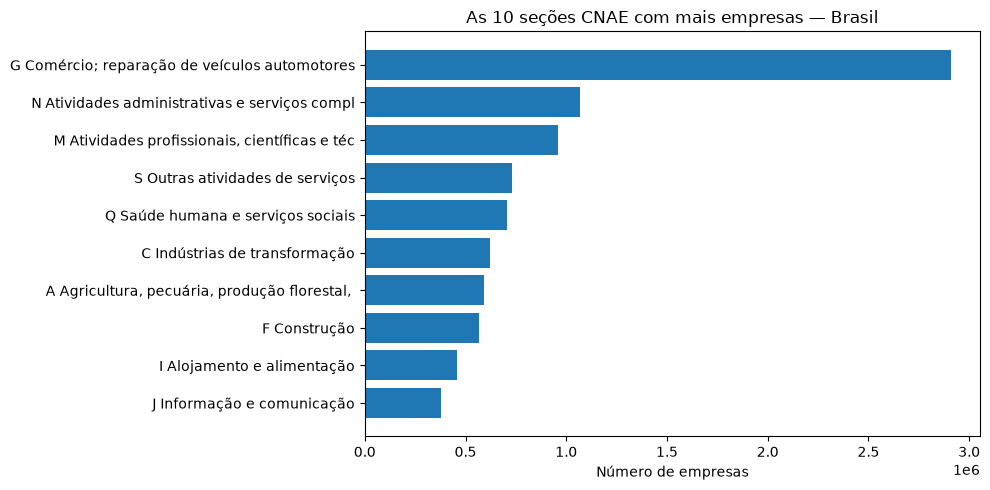

In [8]:
import matplotlib.pyplot as plt

sem_total = brasil[brasil["secao_cnae"] != "Total"]
top10 = sem_total.sort_values("Valor", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10["secao_cnae"].str.slice(0, 45), top10["Valor"])
plt.gca().invert_yaxis()
plt.title("As 10 seções CNAE com mais empresas — Brasil")
plt.xlabel("Número de empresas")
plt.tight_layout()
plt.show()

**Sua vez.** Repita a análise para o **Maranhão**. Na chamada da API, o nível territorial
`"3"` significa Unidade da Federação, e cada estado tem um código do IBGE — o do Maranhão
é **21**. Complete a célula:

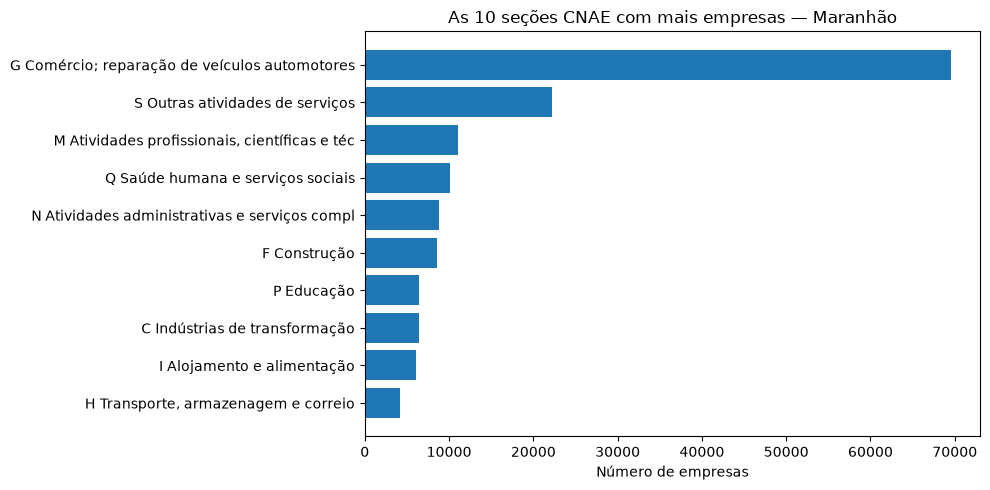

In [9]:
dados_ma = sidrapy.get_table(
    table_code="9582",
    territorial_level="3",              # 3 = Unidade da Federação
    ibge_territorial_code="21",         # 21 = Maranhão
    variable="2585",
    classifications={"12762": "all"},
    period="last",
)

maranhao = limpa_sidra(dados_ma)
maranhao = maranhao.rename(
    columns={"Classificação Nacional de Atividades Econômicas (CNAE 2.0)": "secao_cnae"})

sem_total_ma = maranhao[maranhao["secao_cnae"] != "Total"]
top10_ma = sem_total_ma.sort_values("Valor", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10_ma["secao_cnae"].str.slice(0, 45), top10_ma["Valor"])
plt.gca().invert_yaxis()
plt.title("As 10 seções CNAE com mais empresas — Maranhão")
plt.xlabel("Número de empresas")
plt.tight_layout()
plt.show()

> **📌 Nota de condução** — Se a API falhar em aula, o CSV de contingência é dados/cempre_maranhao.csv (mesmo fluxo da célula de contingência do Brasil). Na discussão, conduza a comparação: a estrutura maranhense é mais concentrada em comércio que a nacional? Essa é a primeira 'análise' da turma — peça que dois ou três estudantes verbalizem a leitura antes de seguir.

## Seção 5 — Perguntas de interpretação

Responda **por escrito**, editando esta célula (clique duas vezes sobre ela):

**1. O que os dois gráficos mostram?** Compare a distribuição das empresas por atividade no
Brasil e no Maranhão.

*Sua resposta:*

**2. O que estes dados NÃO permitem afirmar?** Dê um exemplo de conclusão que seria apressada.

*Sua resposta:*

**3. Que pergunta sobre empresas, mercados ou economia você gostaria de responder com dados
neste semestre?** (Esta resposta será o ponto de partida do seu projeto individual.)

*Sua resposta:*

> **📌 Nota de condução** — Recolha os links dos notebooks ao final e leia as respostas da pergunta 3 antes do encontro 3: elas orientam a apresentação do cardápio de temas do projeto individual. Resposta esperada na pergunta 2: os dados são um retrato (estoque) — não mostram abertura/fechamento, faturamento nem informalidade.

---
### Antes de sair

1. Salve o notebook (`Ctrl+S`) e compartilhe o link com o professor;
2. **Tarefa para o próximo encontro:** ler o capítulo indicado de GIL (2019) sobre pesquisa
social e seus tipos;
3. Se o Colab não funcionou na sua conta, resolva durante a semana — não deixe para a
próxima aula.